The goal here is to do a *single* forward model that could be compared to a single MSA exposure.  The intent here is to work out all the steps, get rough timing, and use that to determine which need further optimization.  All relevant notebooks start with `single_forward_model`.

The slit to work on was identified in [single_forward_model1_target.ipynb](single_forward_model1_target.ipynb)

In [1]:
import re
import pickle
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy import visualization as viz
viz.quantity_support()
from jwst import datamodels

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

# Load Data and Information

In [2]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

In [3]:
apogee_id = '2M19210086+3745339'
apogee_vhelio_avg = -45.42058
apogee_vunc = 0.1100559
apogee_teff = 4416.742
apogee_logg = 2.269546
apogee_m_h = 0.34755

apogee_feh = np.log10(apogee_m_h)

# Find a matching phoenix model and load it

In [4]:
phoenix_model_paths = [path for path in Path('../phoenix/fullgrid').glob('*.fits') if 'WAVE' not in path.name]
teffgz = [re.match(r'lte(\d*)-(.{4})(.{4}).PHOENIX-ACES.*', fn.name).groups() for fn in phoenix_model_paths]
teffgz = np.array([([float(e) for e in t]) for t in teffgz]).T

wavefn = [path for path in Path('../phoenix/fullgrid').glob('*.fits') if 'WAVE' in path.name]
assert len(wavefn) == 1
with fits.open(wavefn[0]) as f:
    wavehdu = f[0]
    ph_wave = wavehdu.data << u.Unit(wavehdu.header['UNIT'])

np.int64(117)

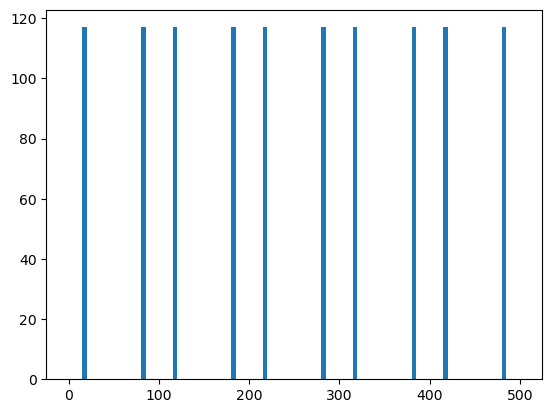

In [5]:
plt.hist(np.abs(teffgz[0] - apogee_teff), bins=100, range=[0, 500])
tempmatch = np.abs(teffgz[0] - apogee_teff) < 50
np.sum(tempmatch)

np.int64(9)

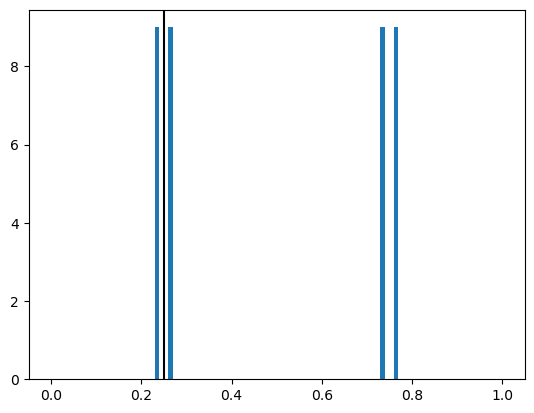

In [6]:
plt.hist(np.abs(teffgz[1, tempmatch]- apogee_logg), bins=100, range=(0, 1))

plt.axvline(.25, c='k')
loggmatch = np.abs(teffgz[1] - apogee_logg) < .25
np.sum(tempmatch & loggmatch)

np.int64(1)

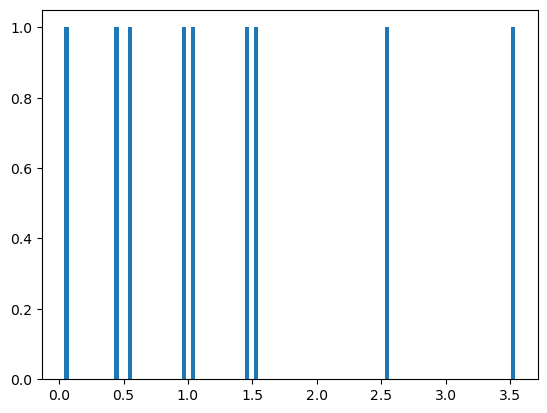

In [7]:
plt.hist(np.abs(teffgz[2, tempmatch&loggmatch]- apogee_feh), bins=100)
fehmatch = np.abs(teffgz[2] - apogee_feh) < .25
np.sum(tempmatch & loggmatch & fehmatch)

In [8]:
assert np.sum(tempmatch & loggmatch & fehmatch) == 1
ph_index = np.where(tempmatch & loggmatch & fehmatch)[0][0]
ph_path = phoenix_model_paths[ph_index]
teffgz[:, tempmatch & loggmatch & fehmatch], ph_path

(array([[ 4.4e+03],
        [ 2.5e+00],
        [-5.0e-01]]),
 PosixPath('../phoenix/fullgrid/lte04400-2.50-0.5.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'))

In [9]:
ph_wave

<Quantity [  500.  ,   500.1 ,   500.2 , ..., 54999.25, 54999.5 , 54999.75] Angstrom>

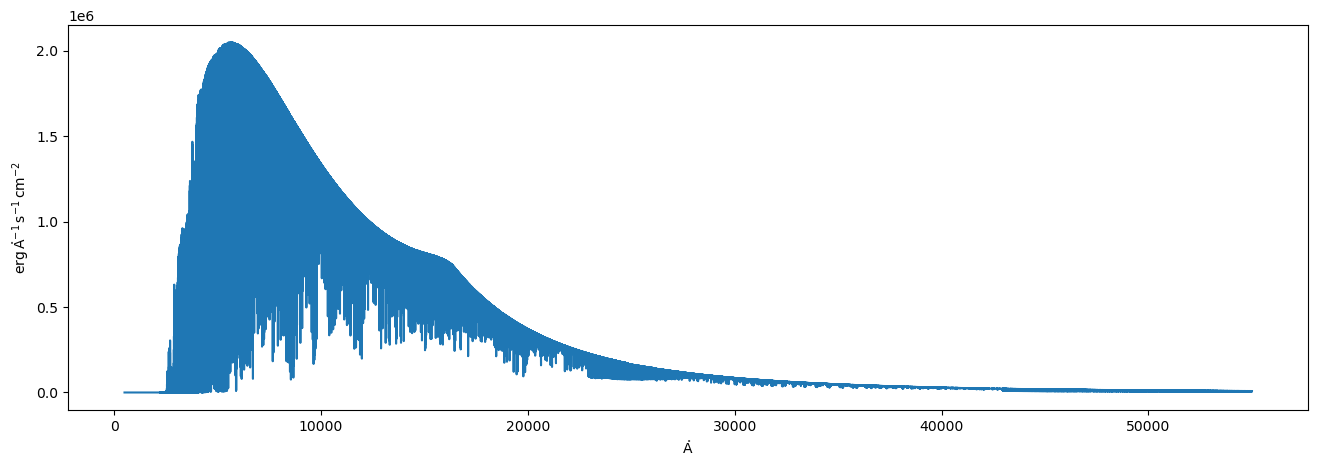

In [10]:
ph_model = fits.getdata(ph_path,0) << u.Unit(fits.getheader(ph_path,0)['BUNIT'])

#we arbitrarily rescale so that the peak is  1 per wave unit
#ph_model = ph_model / np.max(ph_model) / ph_wave.unit

ph_model = ph_model.to(ph_model.unit*u.cm/ph_wave.unit)

plt.figure(figsize=(16, 5))
plt.plot(ph_wave, ph_model);

# Resample to something closer to the data

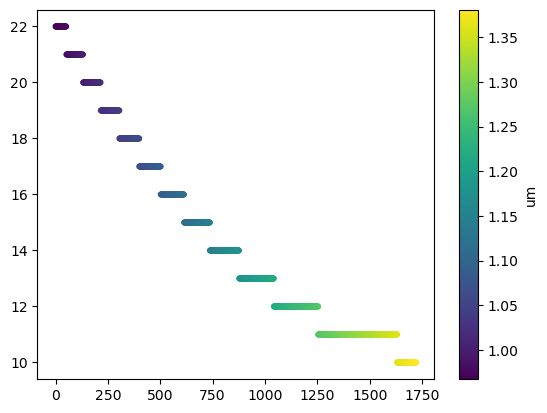

In [11]:
y, x = np.indices(slit.data.shape)
sky, spec = swcs.pixel_to_world(x, y)
densespec = np.linspace(np.nanmin(spec), np.nanmax(spec), x.shape[-1]*3)
source_sky = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')

xdense, ydense = swcs.world_to_pixel(source_sky, densespec)

xdr = np.round(xdense - .5)
ydr = np.round(ydense - .5)
pixelsets = set([(x,y) for x,y in zip(xdr, ydr) if np.isfinite(x) and np.isfinite(y)])
upix = np.array(list(pixelsets))
upix = upix[np.argsort(upix[:, 0])]

uwl = swcs.pixel_to_world(upix[:, 0], upix[:, 1])[-1]

plt.scatter(upix[:, 0], upix[:, 1], c=uwl.value, s=10)
plt.colorbar().set_label(uwl.unit)

(<SpectralCoord 2.40316794 Angstrom>, <SpectralCoord 2.39364441 Angstrom>)

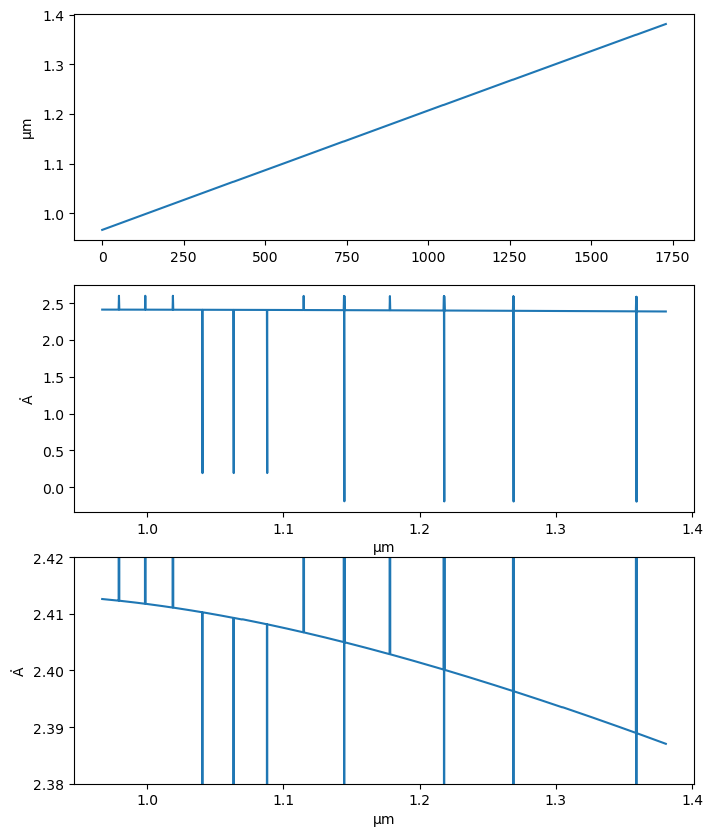

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))
ax1.plot(uwl)
ax2.plot(uwl[:-1], np.diff(uwl).to(u.angstrom))
ax3.plot(uwl[:-1], np.diff(uwl).to(u.angstrom))
ax3.set_ylim(2.38, 2.42)
np.median(np.diff(uwl).to(u.angstrom)), np.mean(np.diff(uwl).to(u.angstrom))

This suggests that 1 angstrom resolution is sufficient for the model spectrum.  But lets try to do a bit better than that.

Text(0, 0.5, 'dispersion (angstrom)')

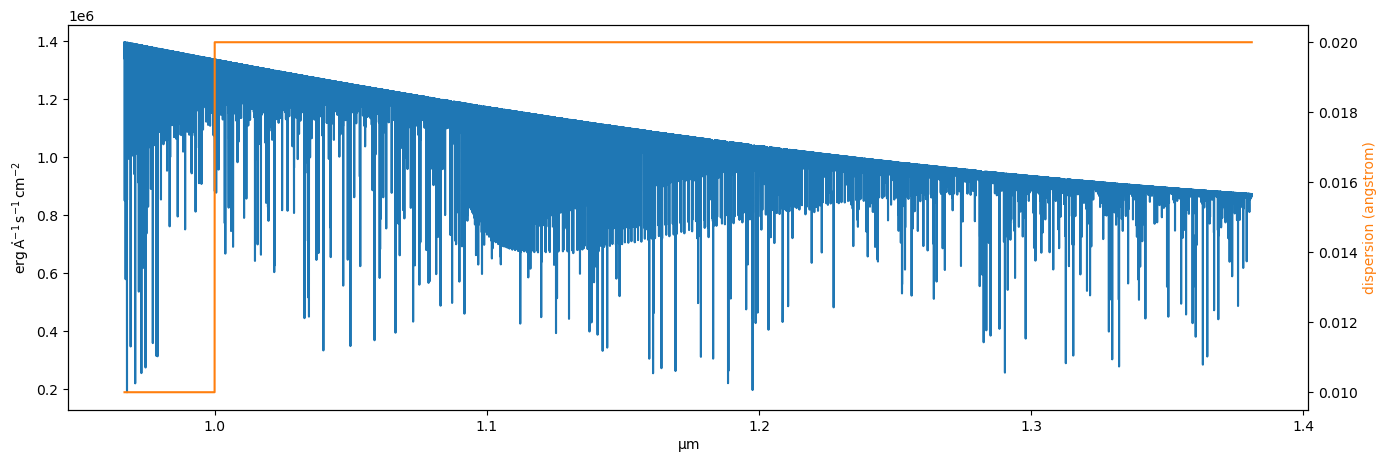

In [16]:
plt.figure(figsize=(16, 5))
msk = (densespec[0] < ph_wave) & (ph_wave < densespec[-1])
plt.plot(ph_wave[msk].to(u.um), ph_model[msk])
plt.twinx()
plt.plot(ph_wave[msk].to(u.um)[:-1],np.diff(ph_wave[msk].to(u.angstrom)), c='C1')
plt.ylabel('dispersion (angstrom)', c='C1')

In [17]:
target_spacing = 0.5 * u.angstrom
resample_factor = int(round(target_spacing/np.max(np.diff(ph_wave[msk].to(u.angstrom)))))

resample_factor


25

Text(0, 0.5, 'dispersion (angstrom)')

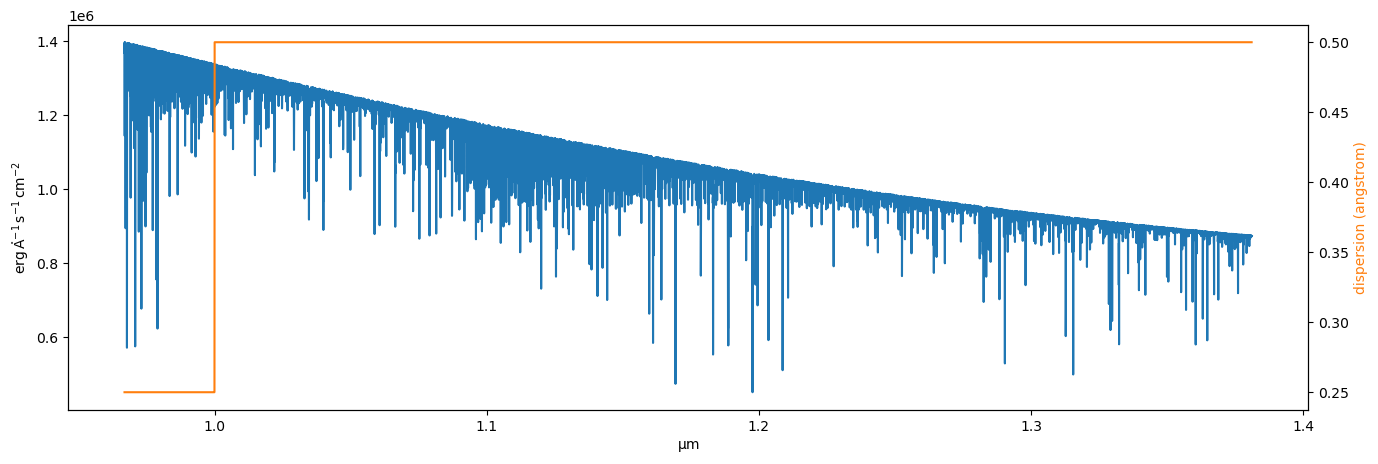

In [18]:
msk = (densespec[0] < ph_wave) & (ph_wave < (densespec[-1]+target_spacing))
cutoff_len = int(np.sum(msk)/resample_factor)*resample_factor

re_wave = ph_wave[msk][:cutoff_len].reshape(-1, resample_factor)
re_model = ph_model[msk][:cutoff_len].reshape(-1, resample_factor)

re_wave = np.mean(re_wave, axis=1)
re_model = np.mean(re_model, axis=1)

plt.figure(figsize=(16, 5))
plt.plot(re_wave.to(u.um), re_model)
plt.twinx()
plt.plot(re_wave.to(u.um)[:-1],np.diff(re_wave.to(u.angstrom)), c='C1')
plt.ylabel('dispersion (angstrom)', c='C1')

# Save for use in later notebooks

In [19]:
with open('single_forward_model_model_spec.pkl', 'wb') as f:
    pickle.dump(dict(wave=re_wave, model=re_model, phoenix_path=ph_path), f)